# 09 — Florence-2 Caption Phrase Grounding Annotation (M_cpg prep)

Runs Florence-2 `<CAPTION_TO_PHRASE_GROUNDING>` over all Flickr30k **train** images
and saves `cpg_annotations.json` to Google Drive.

**Key difference from `07_florence2_annotate.ipynb`:**  
`<DENSE_REGION_CAPTION>` generates verbose Florence-2 descriptions ("a woman in a blue top")  
that don't match the short noun-phrase style used in Flickr30k evaluation.  
`<CAPTION_TO_PHRASE_GROUNDING>` takes the Flickr30k caption as input and grounds  
its own phrases — so labels are in exactly the same vocabulary as evaluation.

| Cell | Purpose |
|------|--------|
| 0 | Install deps |
| 1 | Imports |
| 2 | Mount Drive + load Flickr30k |
| 3 | Download + patch Florence-2 |
| 4 | Run annotation (resume-safe) |
| 5 | Verify output |

**Output format:** `{filename: {"caption": "...", "bboxes": [[x1,y1,x2,y2],...], "labels": [...]}}`  
The `caption` field stores which Flickr30k caption was used, so training can use the same one for global loss alignment.

**Run once.** After this completes, run `10_train_mcpg.ipynb` for M_cpg training.

**Time:** ~60–90 min on L4 GPU (~29k images, variable-length caption inputs).

**Resume-safe:** re-running cell 4 skips already-annotated images.


In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.38.2',
    'datasets', 'huggingface_hub', 'tqdm', 'Pillow',
], check=True)
print('Dependencies installed.')


Dependencies installed.


In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import gc, io, json, os, random, re, shutil, sys, zipfile
from pathlib import Path

import torch
from PIL import Image as PILImage
from tqdm.auto import tqdm
from datasets import load_dataset
from huggingface_hub import HfApi, hf_hub_download, snapshot_download
from transformers import AutoProcessor, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM free: 42.0 GB


In [3]:
# ── 2. Mount Drive + load Flickr30k ──────────────────────────────────────────
from google.colab import drive

GDRIVE_ROOT = Path('/content/drive')
drive.mount(str(GDRIVE_ROOT))

GDRIVE_ZIP  = GDRIVE_ROOT / 'MyDrive' / 'region-grounded-data' / 'flickr30k_full.zip'
LOCAL_DATA  = Path('data/flickr30k')
PQ_DIR      = LOCAL_DATA / 'parquet'

if GDRIVE_ZIP.exists():
    sz_gb = GDRIVE_ZIP.stat().st_size / 1e9
    print(f'Drive cache found ({sz_gb:.1f} GB). Extracting parquets...')
    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(str(GDRIVE_ZIP)) as zf:
        members = [m for m in zf.namelist() if 'parquet' in m]
        zf.extractall('.', members=members)
    print(f'Extracted {len(members)} parquet shards.')
else:
    import urllib.request
    PQ_DIR.mkdir(parents=True, exist_ok=True)
    HF_TOKEN = os.environ.get('HF_TOKEN') or __import__('getpass').getpass('HF token: ')
    os.environ['HF_TOKEN'] = HF_TOKEN
    REPO_ID  = 'nlphuji/flickr30k'
    api      = HfApi(token=HF_TOKEN)
    pq_names = sorted(
        f for f in api.list_repo_files(REPO_ID, repo_type='dataset',
                                        revision='refs/convert/parquet')
        if f.endswith('.parquet')
    )
    print(f'Downloading {len(pq_names)} parquet shard(s)...')
    for fname in pq_names:
        cached = hf_hub_download(
            repo_id=REPO_ID, filename=fname, repo_type='dataset',
            revision='refs/convert/parquet', token=HF_TOKEN,
        )
        shutil.copy(cached, PQ_DIR / Path(fname).name)
    print('Parquet shards downloaded.')

local_pq   = sorted(str(f) for f in PQ_DIR.glob('*.parquet'))
hf_data    = load_dataset('parquet', data_files={'data': local_pq})['data']
train_rows = [r for r in hf_data if r['split'] == 'train']
print(f'Flickr30k total rows: {len(hf_data):,}')
print(f'Train rows: {len(train_rows):,}')


Mounted at /content/drive
Drive cache found (4.4 GB). Extracting parquets...
Extracted 9 parquet shards.


Generating data split: 0 examples [00:00, ? examples/s]

Flickr30k total rows: 31,014
Train rows: 29,000


In [4]:
# ── 3. Download + patch Florence-2 ───────────────────────────────────────────
FLORENCE_LOCAL = Path('florence2_local')

if not FLORENCE_LOCAL.exists():
    print('Downloading Florence-2 base (~885 MB)...')
    snapshot_download(
        repo_id='microsoft/Florence-2-base',
        local_dir=str(FLORENCE_LOCAL),
        ignore_patterns=['*.msgpack', '*.h5'],
    )
    mod_path = FLORENCE_LOCAL / 'modeling_florence2.py'
    src_txt  = mod_path.read_text()
    src_txt  = re.sub(
        r'from flash_attn[^\n]*',
        'pass  # flash_attn stubbed',
        src_txt,
    )
    mod_path.write_text(src_txt)
    print('Downloaded and patched.')
else:
    print('Florence-2 already present locally.')

fl_proc  = AutoProcessor.from_pretrained(str(FLORENCE_LOCAL), trust_remote_code=True)
fl_model = AutoModelForCausalLM.from_pretrained(
    str(FLORENCE_LOCAL),
    trust_remote_code=True,
    torch_dtype=torch.float16,
).to(DEVICE).eval()
print(f'Florence-2 loaded on {DEVICE}.')
if DEVICE == 'cuda':
    print(f'VRAM after load: {(torch.cuda.mem_get_info()[1]-torch.cuda.mem_get_info()[0])/1e9:.1f} GB used')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

SECURITY.md: 0.00B [00:00, ?B/s]

CODE_OF_CONDUCT.md:   0%|          | 0.00/444 [00:00<?, ?B/s]

configuration_florence2.py: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/464M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

Downloaded and patched.
Florence-2 loaded on cuda.
VRAM after load: 0.9 GB used


In [6]:
import time
from concurrent.futures import ThreadPoolExecutor

# ── 4. Run annotation — batched, prefetched, resume-safe ─────────────────────
# Uses <CAPTION_TO_PHRASE_GROUNDING>: takes a Flickr30k caption as input and
# returns (phrase, bbox) pairs grounded from that caption. Labels stay in the
# same short noun-phrase vocabulary as Flickr30k Entities, fixing the
# train/eval vocabulary mismatch in the DENSE_REGION_CAPTION approach.
#
# Output: cpg_annotations.json
#   {filename: {"caption": str, "bboxes": [[x1,y1,x2,y2],...], "labels": [...]}}
#
# Speed: ThreadPoolExecutor overlaps CPU image-decode+preprocess for batch N+1
# with GPU generate for batch N — GPU never idles waiting for CPU.
# BATCH_SIZE=8: A100 has ~38 GB free after model load; 8 images at float16 is
# ~110 MB of pixel_values, very safe. Raise to 16 if you see <50% GPU util.

GDRIVE_ANN = GDRIVE_ROOT / 'MyDrive' / 'region-grounded-data' / 'cpg_annotations.json'
LOCAL_ANN  = LOCAL_DATA / 'cpg_annotations.json'
SAVE_EVERY = 500
TASK       = '<CAPTION_TO_PHRASE_GROUNDING>'
BATCH_SIZE = 8
MAX_TOKENS = 256   # phrase grounding outputs can be longer than dense captions

# Resume from Drive if available
if GDRIVE_ANN.exists():
    shutil.copy(str(GDRIVE_ANN), str(LOCAL_ANN))
    with open(LOCAL_ANN) as f:
        cpg_ann = json.load(f)
    print(f'Resumed: {len(cpg_ann):,} images already annotated.')
else:
    cpg_ann = {}
    print('Starting fresh.')

todo = [r for r in train_rows if r['filename'] not in cpg_ann]
print(f'Remaining: {len(todo):,} / {len(train_rows):,} images')

def decode_pil(row):
    img_field = row['image']
    if isinstance(img_field, PILImage.Image):
        return img_field.convert('RGB')
    return PILImage.open(io.BytesIO(img_field['bytes'])).convert('RGB')

def prepare_batch(batch_rows):
    """CPU work: decode images + run processor. Runs in background thread."""
    pils     = [decode_pil(r) for r in batch_rows]
    captions = [r['caption'][0] for r in batch_rows]
    texts    = [f'{TASK} {cap}' for cap in captions]
    inputs   = fl_proc(
        text=texts, images=pils, return_tensors='pt', padding=True,
    )
    return inputs, pils, captions

batches = [todo[i : i + BATCH_SIZE] for i in range(0, len(todo), BATCH_SIZE)]
n_done_at_last_save = len(cpg_ann)
_checkpoint_t = time.time()

with ThreadPoolExecutor(max_workers=2) as pool:
    # Kick off prefetch of the first batch immediately
    future = pool.submit(prepare_batch, batches[0]) if batches else None

    for i, batch_rows in enumerate(tqdm(batches, desc='Florence-2 CPG')):
        inputs, pils, captions = future.result()   # CPU work done (or wait for it)

        # Prefetch next batch in background while GPU runs this one
        if i + 1 < len(batches):
            future = pool.submit(prepare_batch, batches[i + 1])

        inputs = inputs.to(DEVICE, torch.float16)

        with torch.no_grad():
            ids = fl_model.generate(
                input_ids      = inputs['input_ids'],
                pixel_values   = inputs['pixel_values'],
                max_new_tokens = MAX_TOKENS,
                num_beams      = 1,
                do_sample      = False,
            )

        out_texts = fl_proc.batch_decode(ids, skip_special_tokens=False)
        for out_text, pil, row, caption in zip(out_texts, pils, batch_rows, captions):
            parsed = fl_proc.post_process_generation(
                out_text, task=TASK, image_size=(pil.width, pil.height)
            )
            result = parsed[TASK]
            cpg_ann[row['filename']] = {
                'caption': caption,
                'bboxes':  result['bboxes'],
                'labels':  result['labels'],
            }

        # Checkpoint every SAVE_EVERY images
        if len(cpg_ann) // SAVE_EVERY > n_done_at_last_save // SAVE_EVERY:
            LOCAL_ANN.parent.mkdir(parents=True, exist_ok=True)
            with open(LOCAL_ANN, 'w') as f:
                json.dump(cpg_ann, f)
            shutil.copy(str(LOCAL_ANN), str(GDRIVE_ANN))
            _elapsed = time.time() - _checkpoint_t
            _remaining = len(todo) - (len(cpg_ann) - (len(train_rows) - len(todo)))
            _eta_min = _remaining / SAVE_EVERY * _elapsed / 60
            print(f'  checkpoint: {len(cpg_ann):,} done | last 500 in {_elapsed:.0f}s | ETA ~{_eta_min:.0f} min')
            n_done_at_last_save = len(cpg_ann)
            _checkpoint_t = time.time()

# Final save
LOCAL_ANN.parent.mkdir(parents=True, exist_ok=True)
with open(LOCAL_ANN, 'w') as f:
    json.dump(cpg_ann, f)
shutil.copy(str(LOCAL_ANN), str(GDRIVE_ANN))
print(f'\nSaved to {GDRIVE_ANN}')

n_reg = sum(len(v['bboxes']) for v in cpg_ann.values())
print(f'{len(cpg_ann):,} images annotated')
print(f'{n_reg:,} total regions ({n_reg/len(cpg_ann):.1f} per image avg)')


Starting fresh.
Remaining: 29,000 / 29,000 images


Florence-2 CPG:   0%|          | 0/3625 [00:00<?, ?it/s]

  checkpoint: 504 done | last 500 in 42s | ETA ~40 min
  checkpoint: 1,000 done | last 500 in 44s | ETA ~41 min
  checkpoint: 1,504 done | last 500 in 43s | ETA ~40 min
  checkpoint: 2,000 done | last 500 in 41s | ETA ~37 min
  checkpoint: 2,504 done | last 500 in 44s | ETA ~39 min
  checkpoint: 3,000 done | last 500 in 43s | ETA ~37 min
  checkpoint: 3,504 done | last 500 in 42s | ETA ~36 min
  checkpoint: 4,000 done | last 500 in 43s | ETA ~36 min
  checkpoint: 4,504 done | last 500 in 40s | ETA ~33 min
  checkpoint: 5,000 done | last 500 in 44s | ETA ~35 min
  checkpoint: 5,504 done | last 500 in 43s | ETA ~33 min
  checkpoint: 6,000 done | last 500 in 41s | ETA ~32 min
  checkpoint: 6,504 done | last 500 in 49s | ETA ~37 min
  checkpoint: 7,000 done | last 500 in 40s | ETA ~30 min
  checkpoint: 7,504 done | last 500 in 42s | ETA ~30 min
  checkpoint: 8,000 done | last 500 in 42s | ETA ~29 min
  checkpoint: 8,504 done | last 500 in 43s | ETA ~30 min
  checkpoint: 9,000 done | last 5

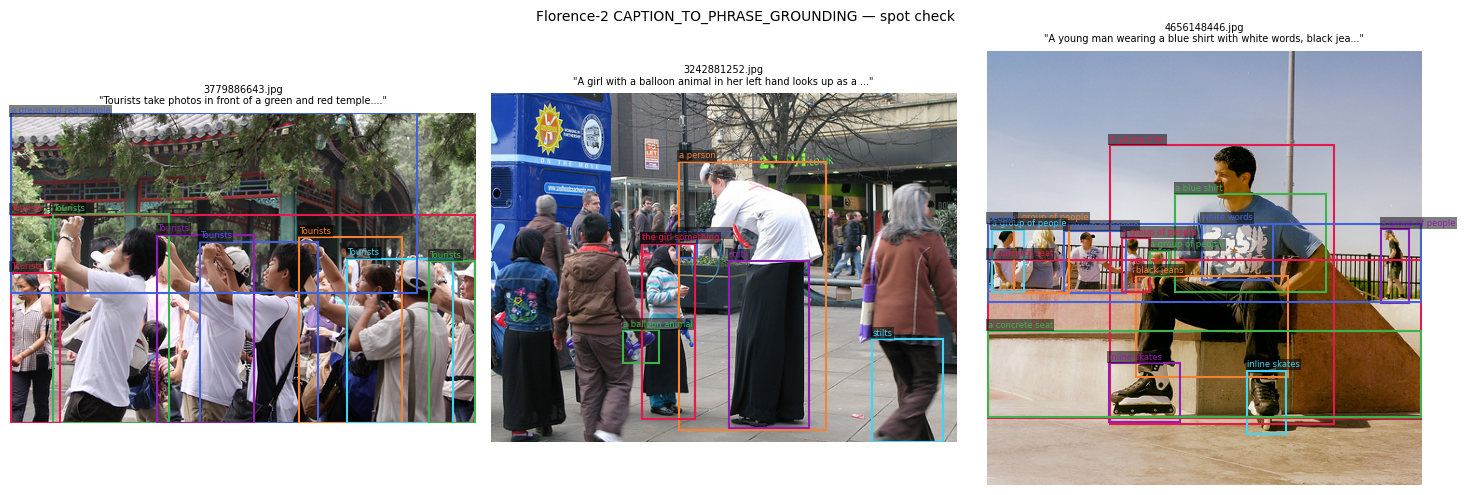

Verification complete. cpg_annotations.json is ready for 10_train_mcpg.ipynb.


In [7]:
# ── 5. Verify output ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

samples = random.sample(list(cpg_ann.items()), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4']

for ax, (fname, ann) in zip(axes, samples):
    row = next(r for r in train_rows if r['filename'] == fname)
    img_field = row['image']
    if isinstance(img_field, PILImage.Image):
        pil = img_field.convert('RGB')
    else:
        pil = PILImage.open(io.BytesIO(img_field['bytes'])).convert('RGB')

    ax.imshow(pil)
    ax.set_title(f'{fname}\n"{ann["caption"][:60]}..."', fontsize=7)
    ax.axis('off')

    for i, (bbox, label) in enumerate(zip(ann['bboxes'], ann['labels'])):
        x1, y1, x2, y2 = bbox
        color = COLORS[i % len(COLORS)]
        rect  = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                    linewidth=1.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, max(y1-4, 0), label, fontsize=6, color=color,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))

plt.suptitle('Florence-2 CAPTION_TO_PHRASE_GROUNDING — spot check', fontsize=10)
plt.tight_layout()
plt.show()
print('Verification complete. cpg_annotations.json is ready for 10_train_mcpg.ipynb.')
